## NumPy 手动实现线性回归

In [220]:
import numpy as np
import matplotlib.pyplot as plt

In [221]:
# y = 1.234x + 0.567 + eps, 其中eps~N(0,4)
# 用 Python 生成 1000 组带高斯噪声的线性回归样本数据，真实模型是 y = 1.234x + 0.567 + ε，其中噪声 ε 服从均值为 0、标准差为 2 的正态分布
datas = []
for i in range(1000): # 生成 1000 组样本数据
    # 随机生成输入x
    x = np.random.uniform(-10,10) # 生成在区间 [-10,10] 上均匀分布的随机数                uniform → 均匀分布（在指定范围里随机取数）
    # 生成高斯噪声 eps                                                                 rand   → 简化版 uniform（固定 0~1 之间均匀）
    eps = np.random.normal(0,2)   # 生成均值为 0、标准差为 2 的正态分布（高斯分布）随机数     normal  → 正态分布（中间多、两边少，高斯分布）
    # 生成输出y                                                                       randn  → 简化版 normal（固定 均值 0、方差 1 的标准正态）
    y = 1.234 * x + 0.567 + eps
    datas.append([x,y])
datas = np.array(datas)  # 形状 (1000, 2)：1000 行（1000 个样本），2 列（x 和 y 两个特征）
print(datas.shape)

(1000, 2)


In [222]:
datas   # 得到的是1000组样本数据，x是[-10,10]之间均匀分布

array([[-9.58395493, -9.98191508],
       [-6.0248508 , -9.92818706],
       [ 2.9196529 ,  6.77574142],
       ...,
       [ 4.92227218,  3.47851378],
       [ 3.97382484,  5.77035325],
       [ 0.94507513,  2.85254191]], shape=(1000, 2))

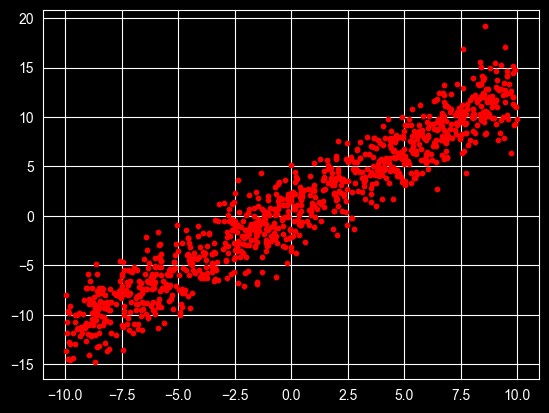

In [223]:
plt.scatter(datas[:,0], datas[:,1], marker = 'o',color = 'red', s = 10 ,label = 'First')

## 计算误差

In [224]:
# 计算每个点的预测值与真实值之间的mse，累加得到整个数据集上的均方差损失
def mse(w,b,points): # points：输入的数据集
    totalError = 0
    for i in range(len(points)):
        x = points[i,0]   # 输入x
        y = points[i,1]   # 真实输出y
        y_pred = w*x+b    # 预测输出y_pred
        totalError += (y - y_pred) **2
    #求平均，返回均方差mse    
    return totalError/float(len(points))
# 之前生成的噪声 eps ~ N(0, 2)，方差为 标准差**2=4，所以用真实 w=1.234、b=0.567 计算 MSE 时，结果会无限接近 4，完美验证了数据生成的正确性。

## 计算梯度

In [225]:
def gradient(w,b,points,lr):
    b_grad = 0
    w_grad = 0
    N = float(len(points))
    for i in range(len(points)):
        x = points[i,0]
        y = points[i,1]
        w_grad += (2/N) * (w*x+b - y) * x
        b_grad += (2/N) * (w*x+b - y)
    new_w = w - lr * w_grad
    new_b = b - lr * b_grad
    return new_w, new_b

## 梯度更新

In [226]:
def gradient_descent(points,start_w,start_b,lr,epochs):  # 梯度下降
    w = start_w
    b = start_b
    losses = []
    for epoch in range(epochs):
        w, b = gradient(w,b,np.array(points),lr)
        loss = mse(w,b,points)
        losses.append(loss)
        if epoch % 50 == 0:
            print('epoch:{}, loss:{}'.format(epoch,loss))
    return w,b,losses

In [227]:
lr = 0.01
start_w = 0
start_b = 0
epochs = 1000
w,b,losses = gradient_descent(datas,start_w,start_b,lr,epochs)
f_loss = mse(w,b,datas)
print('Final loss:{}'.format(f_loss))

epoch:0, loss:10.344901762886304
epoch:50, loss:4.292948978084085
epoch:100, loss:4.259124664929484
epoch:150, loss:4.254625839226712
epoch:200, loss:4.254027469864066
epoch:250, loss:4.253947883341318
epoch:300, loss:4.253937297881905
epoch:350, loss:4.253935889955698
epoch:400, loss:4.253935702693518
epoch:450, loss:4.253935677786588
epoch:500, loss:4.25393567447382
epoch:550, loss:4.253935674033198
epoch:600, loss:4.253935673974595
epoch:650, loss:4.253935673966799
epoch:700, loss:4.25393567396577
epoch:750, loss:4.25393567396563
epoch:800, loss:4.253935673965616
epoch:850, loss:4.253935673965612
epoch:900, loss:4.253935673965608
epoch:950, loss:4.253935673965611
Final loss:4.253935673965607


Text(0, 0.5, 'MSE')

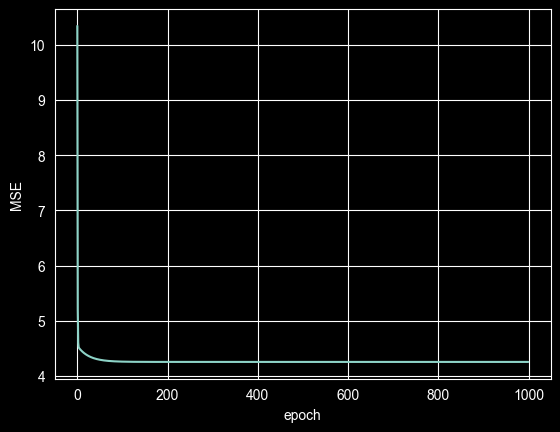

In [228]:
# plt.plot() 画直线、看趋势   plt.scatter() 画散点、看分布
plt.plot(losses)
plt.xlabel('epoch')
plt.ylabel('MSE')

In [229]:
print(w,b)

1.228305669563249 0.5612313019469156


# 利用Pytorch框架实现线性回归

## 构造数据

In [230]:
import torch
import numpy as np

num_examples = 1000  # 样本数量（1000个数据点）
num_inputs = 1       # 输入特征数（单变量线性回归，所以是1）
w = 1.234
b = 0.567
# 生成1000行1列、[-10,10]均匀分布的numpy数组. 转成PyTorch张量（共享内存，零拷贝）
x = torch.from_numpy(np.random.uniform(-10,10,(num_examples,num_inputs))).to(torch.float32)
y = w*x+b
y += torch.from_numpy(np.random.normal(0,0.5,size=y.size())).to(torch.float32)  # 生成均值0、标准差0.5的正态分布噪声

x_clone = x.clone()
y_clone = y.clone()
# 方案2：如果需要拷贝张量，用.detach().clone()（仅当需要完全隔离原数据时用）
# x = torch.from_numpy(np.random.uniform(-10,10,(num_examples,num_inputs))).detach().clone().to(torch.float32)

In [231]:
# 这个函数是深度学习训练的核心工具，作用是：把完整数据集拆分成小批量（batch），并随机打乱顺序，用 yield 实现高效内存管理。
# 核心目的：实现随机小批量梯度下降（Mini-Batch GD），这是深度学习训练的标准方式
def data_iter(batch_size,features,labels): # 样本数,特征张量,标签张量
    num_examples = len(features)         # 1000
    indices = list(range(num_examples))  # 生成 [0, 1, 2, ..., 999] 的列表
    np.random.shuffle(indices)  # 随机打乱索引顺序,避免模型学习到顺序规律，提升泛化能力 (训练集→必须打乱, 测试集/验证集→不用打乱)
    for i in range(0, num_examples, batch_size):
        j = torch.LongTensor(indices[i: min(i + batch_size,num_examples)]) # 从打乱的索引中，截取 i 到 i+batch_size 的片段.
        # min(...) 是为了处理最后一个 batch：当剩余样本数不足 batch_size 时，只取到最后一个样本，避免索引越界
        # torch.LongTensor()：把 Python 列表转成 64 位整数张量.  原因：PyTorch 的 index_select 要求索引必须是 LongTensor（整数类型），不能用浮点数或普通列表
        yield features.index_select(0, j), labels.index_select(0,j)  # 输出：通过 yield 逐个返回小批量的 (特征，标签) 对
        # index_select(dim, 数字) = 在第?维度（行/列）上，挑选数字指定的那些行

        # return：一次性返回所有数据，会把 1000 个样本全部加载到内存，内存占用高
        # yield： 每次只返回一个 batch 的数据，用完即弃，不占用额外内存，这就是「yield 节约内存」的核心原理

In [232]:
batch_size = 10
for xx,yy in data_iter(batch_size,x,y):
    print(xx)
    print(yy)
    break

tensor([[ 7.1586],
        [-7.1798],
        [-4.3600],
        [-0.1682],
        [ 5.5846],
        [-7.7845],
        [ 7.6486],
        [ 1.9721],
        [ 4.0211],
        [-1.8548]])
tensor([[ 9.2565],
        [-7.4085],
        [-4.7152],
        [ 0.3625],
        [ 7.1876],
        [-8.3936],
        [ 9.3042],
        [ 2.8526],
        [ 5.8120],
        [-1.8041]])


In [233]:
# 上面的写法是手写数据迭代器，实际项目中，PyTorch 提供了更简洁的原生 API：
from torch.utils.data import TensorDataset, DataLoader

print(f"原始x shape: {x.shape}")
print(f"原始y shape: {y.shape}")
print(f"x_clone shape: {x_clone.shape}")
print(f"y_clone shape: {y_clone.shape}")
# 把特征和标签打包成数据集
dataset = TensorDataset(x_clone, y_clone)
# 用 DataLoader 生成批量数据，自动打乱、分 batch
dataloader = DataLoader(dataset, batch_size=300, shuffle=True)

# 直接遍历 dataloader 即可
for X, y in dataloader:
    print(X.shape, y.shape)

原始x shape: torch.Size([1000, 1])
原始y shape: torch.Size([1000, 1])
x_clone shape: torch.Size([1000, 1])
y_clone shape: torch.Size([1000, 1])
torch.Size([300, 1]) torch.Size([300, 1])
torch.Size([300, 1]) torch.Size([300, 1])
torch.Size([300, 1]) torch.Size([300, 1])
torch.Size([100, 1]) torch.Size([100, 1])


## 初始化参数  构造模型

In [234]:
# 用NumPy生成均值为0、标准差为0.01的正态分布随机数，形状为(num_inputs, 1)（num_inputs=1，所以是 (1,1) 的二维张量）. 再转成PyTorch张量，指定数据类型为float32（深度学习默认精度）
w = torch.tensor(np.random.normal(0, 0.01, (num_inputs,1)), dtype=torch.float32)  # 小标准差（0.01）保证初始预测值不会过大，训练更稳定
b = torch.zeros(1, dtype=torch.float32)
# 只有开启 requires_grad=True，PyTorch 才会在计算图中记录 w 和 b 的梯度，后续才能用梯度下降更新参数
w.requires_grad_(requires_grad=True)
b.requires_grad_(requires_grad=True)

# 更简洁的参数初始化，纯PyTorch原生，无需NumPy，更符合PyTorch习惯
# w = torch.normal(0, 0.01, size=(num_inputs, 1), dtype=torch.float32, requires_grad=True)
# b = torch.zeros(1, dtype=torch.float32, requires_grad=True)

def linear_reg(x,w,b):
    return torch.mm(x,w)+b  # x.shape(1000,1)  w.shape(1,1)  x@w=(1000,1)的张量
#   return x @ w + b  ( @ 是 PyTorch 主流写法)

## 计算loss  更新参数

In [235]:
def loss(y_pred,y):
    return (y_pred-y)**2 / y.shape[0]   #注意返回的是向量

# 手动实现梯度下降核心逻辑，相当于 PyTorch 内置 optim.SGD 的底层原理
def sgd(params,lr,batch_size):
    for param in params:
        param.data -= lr*param.grad / batch_size
        # param 是张量对象，param.grad 存着梯度，param.data 才是真正存数值的地方

# loss = torch.nn.MSELoss()                  官方 Loss
# optimizer = torch.optim.SGD(params, lr=lr)    官方 SGD

## 模型训练

In [236]:
lr = 0.01
epochs = 100
total_loss = []
for epoch in range(epochs):  # 外层遍历完整数据集
    for xx,yy in data_iter(batch_size,x_clone,y_clone):  # 内层遍历 batch，小批量梯度下降
        l = loss(linear_reg(xx,w,b),yy).sum()  # 前向传播算预测 + 计算损失
        l.backward()   # 反向传播算梯度 (pytorch框架自带的计算梯度公式，无需手动推导公式)
        sgd([w,b],lr,batch_size)  # 梯度下降更新参数 w 和 b
        '''
        假设 w 初始值是 0.01，backward() 算出它的梯度是 10.0：
        w 张量：w = tensor(0.01, requires_grad=True)
        backward() 执行后：w.grad = tensor(10.0)
        sgd 拿到 w，读取 w.grad，然后更新 w.data: w.data = 0.01 - lr * 10.0 / batch_size
        [w, b] 始终是那个原始参数，只是它的 .grad 和 .data 被修改了
        只有 requires_grad=True 的张量，才有 .grad 属性
        '''
        w.grad.zero_()
        b.grad.zero_()
        # 为什么必须清零？ PyTorch 默认累积梯度，如果不清零，上一个 batch 的梯度会和下一个 batch 的梯度叠加，导致参数更新错误
    cur_loss = loss(linear_reg(x_clone,w,b),y_clone)  # 记录全量损失(用当前参数，在完整 1000 个样本上计算损失，而不是单个 batch)
    total_loss.append(cur_loss.mean().item())  # mean()：对全量损失取平均，得到标量 MSE.  item()：把 PyTorch 标量张量转换成 Python 浮点数，方便存储和打印
    if epoch%10==0:
        print('epoch:%d, loss: %.4f' %(epoch+1,cur_loss.mean().item()))

epoch:1, loss: 0.0005
epoch:11, loss: 0.0003
epoch:21, loss: 0.0002
epoch:31, loss: 0.0002
epoch:41, loss: 0.0002
epoch:51, loss: 0.0002
epoch:61, loss: 0.0002
epoch:71, loss: 0.0002
epoch:81, loss: 0.0002
epoch:91, loss: 0.0002


Text(0, 0.5, 'MSE')

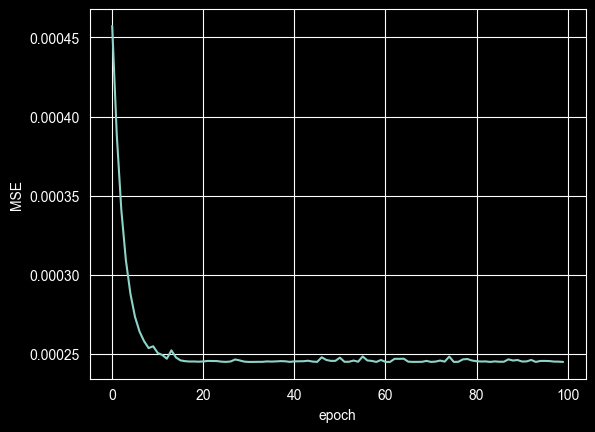

In [237]:
import matplotlib.pyplot as plt
plt.plot(total_loss)
plt.xlabel('epoch')
plt.ylabel('MSE')

In [238]:
print(w)
print(b)

tensor([[1.2345]], requires_grad=True)
tensor([0.5800], requires_grad=True)


## PyTorch 标准实现线性回归

## 利用pytorch 构造数据集

In [239]:
import torch.utils.data as Data
# TensorDataset：数据容器，负责把特征和标签打包成标准数据集
# DataLoader： 数据加载器，负责分 batch、打乱、多线程加载，是训练循环的输入源
dataset = Data.TensorDataset(x_clone,y_clone)
batch_size = 100
data_iter1 = Data.DataLoader(dataset,batch_size,shuffle=True)
print("总样本数:", len(dataset))
print("batch数量:", len(data_iter1))

总样本数: 1000
batch数量: 10


In [240]:
for xx,yy in data_iter1:  # data_iter1 就是装了 10 个批次，每批 100 个样本的数据集 (迭代器)
    print(xx.shape)
    print(yy.shape)
    break

torch.Size([100, 1])
torch.Size([100, 1])


## 自定义模型，并实现前向传播forward函数

In [241]:
import torch.nn as nn
# 定义线性回归模型类，必须继承父类 nn.Module，才能拥有父类所有功能，获得 PyTorch 的自动求导、参数管理、训练支持等能力
class LinearReg(nn.Module):
    def __init__(self,n_features):
        super().__init__()  # 调用父类的构造方法(nn.Module的__init__)，必须写，否则模型无法正常注册参数、运行
        self.linear = nn.Linear(n_features, 1)  # 定义线性层 nn.Linear.
        # 这个层自动帮你初始化权重 w 和偏置 b，并开启 requires_grad=True，彻底替代手写的参数初始化
    def forward(self,x):
        y = self.linear(x)
        return y

# 定义层（nn.Linear(a, b)）：是「造层」，需要传入层的结构参数（输入/输出维度），用来初始化权重
# 使用层（self.linear(x)）：是「用层」，只需要传入输入数据，用已经初始化好的权重计算结果
'''
class Linear(nn.Module):
    # 1. 定义类时的 __init__ 方法：需要2个超参数
    def __init__(self, in_features, out_features, bias=True):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        # 初始化权重w和偏置b
        self.weight = Parameter(torch.empty((out_features, in_features)))
        self.bias = Parameter(torch.empty(out_features)) if bias else None

    # 2. 前向传播的 forward 方法：只需要1个输入数据x
    def forward(self, x):
        return x @ self.weight.T + self.bias  # 用内部的w和b计算
'''

'\nclass Linear(nn.Module):\n    # 1. 定义类时的 __init__ 方法：需要2个超参数\n    def __init__(self, in_features, out_features, bias=True):\n        super().__init__()\n        self.in_features = in_features\n        self.out_features = out_features\n        # 初始化权重w和偏置b\n        self.weight = Parameter(torch.empty((out_features, in_features)))\n        self.bias = Parameter(torch.empty(out_features)) if bias else None\n\n    # 2. 前向传播的 forward 方法：只需要1个输入数据x\n    def forward(self, x):\n        return x @ self.weight.T + self.bias  # 用内部的w和b计算\n'

## 实例化模型

In [242]:
model = LinearReg(num_inputs)  # num_inputs == 1
print('模型:\n',model)
print('w形状:',model.linear.weight.shape)
print('b形状:',model.linear.bias.shape)
for param in model.parameters():  # 遍历所有可训练参数,parameters(): 张量，只有参数值
    print(param)
for name, param in model.named_parameters():
    print(f"参数名: {name}, 形状: {param.shape}, 参数值: {param}")

模型:
 LinearReg(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)
w形状: torch.Size([1, 1])
b形状: torch.Size([1])
Parameter containing:
tensor([[0.1798]], requires_grad=True)
Parameter containing:
tensor([0.1932], requires_grad=True)
参数名: linear.weight, 形状: torch.Size([1, 1]), 参数值: Parameter containing:
tensor([[0.1798]], requires_grad=True)
参数名: linear.bias, 形状: torch.Size([1]), 参数值: Parameter containing:
tensor([0.1932], requires_grad=True)


## 参数初始化（可选）

In [243]:
from torch.nn import init  #  init: 参数初始化工具包
# 虽然 nn.Linear 内置了默认初始化，但可以通过 torch.nn.init 模块完全控制权重和偏置的初始值
init.normal_(model.linear.weight, mean=0, std=0.01)  # 正态分布,均值0,标准差0.01
init.constant_(model.linear.bias, val=0)  # constant_: 设为常数
print(model.linear.weight)
print(model.linear.bias)

Parameter containing:
tensor([[0.0068]], requires_grad=True)
Parameter containing:
tensor([0.], requires_grad=True)


## 定义损失函数

In [244]:
loss = nn.MSELoss()

## 定义优化器（SGD）

In [245]:
import torch.optim as optim  # torch.optim.SGD 和 torch.nn.SGD 本质上是一个东西（功能一致），但工业界习惯用 torch.optim 下的优化器，因为它更专注于优化逻辑，且 API 更统一
optimizer = optim.SGD(model.parameters(), lr=0.01)  # model.parameters()：指定待更新的模型参数（w和b）

In [246]:
import torch
# backward() 是张量 Tensor 自带的自动求导方法，从 import torch 那一刻起就存在
# 但只有满足两个条件，张量才能调用 .backward():
# 1.张量是 标量（一个数，shape=()）
# 2.张量的 requires_grad=True（或者它是由 requires_grad=True 的张量计算出来的）
x = torch.tensor(1.0, requires_grad=True)  # PyTorch 只允许浮点型/复数型张量开启梯度，整数型张量不支持requires_grad=True，所以这里是1.0不能是1
y = x ** 2
print(type(y))   # <class 'torch.Tensor'>
y.backward()     # 可以调用，因为 y 是标量，且可求导.
print(x.grad)    # 查看 x 的梯度  （backward()无返回值,用.grad查看）

<class 'torch.Tensor'>
tensor(2.)


In [247]:
num_epochs = 1000
total_loss = []
for epoch in range(num_epochs):
    for xx, yy in data_iter1:
        output = model(xx)    # 调用模型的 forward 方法，输入特征 xx，计算预测值 output
        '''
        等价于:
        output = model.forward(xx)
        不要手动写 model.forward (xx)！手动写 forward() 会跳过 PyTorch 底层的一些关键处理 (虽然结果一样，但不规范、不推荐这么写)

        nn.Module 这个父类，实现了 __call__ 魔法方法
        只要一个类继承了 nn.Module，这个类的实例就能像函数一样直接调用！调用时 自动执行 forward ()
        '''
        l = loss(output, yy)
        optimizer.zero_grad() # 梯度清零，等价于model.zero_grad()
        l.backward()          # 梯度计算 (执行后，model.linear.weight.grad 和 model.linear.bias.grad 会被赋值为对应梯度)
        optimizer.step()      # 梯度更新 (w=w−lr⋅w.grad，b=b−lr⋅b.grad)
        '''
        每一个 batch 的训练都遵循标准四步流程：
        1.前向传播：output = model(xx)    → 计算预测值
        2.计算损失：l = loss(output, yy)  → 衡量预测误差
        3.反向传播：l.backward()          → 计算参数梯度
        4.参数更新：optimizer.step()      → 根据梯度更新参数
        5.梯度清零：optimizer.zero_grad() → 为下一轮迭代做准备
        '''
    total_loss.append(l.mean().item())  # mean()：对当前批次的损失求均值（MSELoss 默认返回均值，此处可省略，写法更严谨）  item()：将张量 l 转换为 Python 浮点数，方便存储

    if epoch% 10 == 0:
        print('epoch %d, loss: %f' % (epoch, l.mean().item()))

epoch 0, loss: 0.537702
epoch 10, loss: 0.232780
epoch 20, loss: 0.274291
epoch 30, loss: 0.232627
epoch 40, loss: 0.246321
epoch 50, loss: 0.249786
epoch 60, loss: 0.226440
epoch 70, loss: 0.248880
epoch 80, loss: 0.218254
epoch 90, loss: 0.270904
epoch 100, loss: 0.216166
epoch 110, loss: 0.278227
epoch 120, loss: 0.293740
epoch 130, loss: 0.265021
epoch 140, loss: 0.264774
epoch 150, loss: 0.209266
epoch 160, loss: 0.253771
epoch 170, loss: 0.235137
epoch 180, loss: 0.205605
epoch 190, loss: 0.203933
epoch 200, loss: 0.222511
epoch 210, loss: 0.207134
epoch 220, loss: 0.219511
epoch 230, loss: 0.284804
epoch 240, loss: 0.246836
epoch 250, loss: 0.266221
epoch 260, loss: 0.271182
epoch 270, loss: 0.209749
epoch 280, loss: 0.199325
epoch 290, loss: 0.226236
epoch 300, loss: 0.215518
epoch 310, loss: 0.244850
epoch 320, loss: 0.239070
epoch 330, loss: 0.263765
epoch 340, loss: 0.285630
epoch 350, loss: 0.235370
epoch 360, loss: 0.253070
epoch 370, loss: 0.207925
epoch 380, loss: 0.2654

Text(0, 0.5, 'MSE')

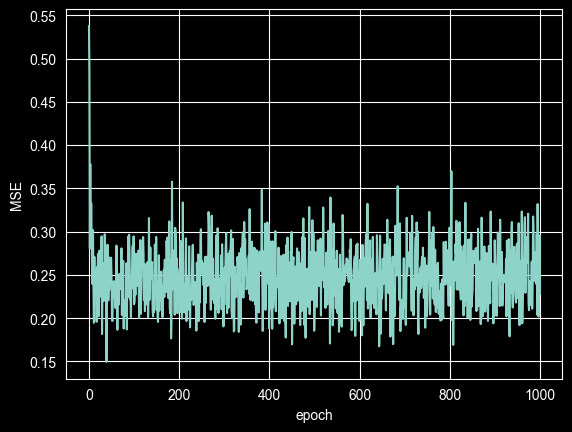

In [248]:
plt.plot(total_loss)
plt.xlabel('epoch')
plt.ylabel('MSE')